Rename the notebook as Lastname.Firstname-A1.ipynb for submission.

1. Import required packages.
2. Get a data file with real estate listings for a town of your choice from redfin.com
3. Select only the following columns from the dataset: 'PROPERTY TYPE', 'PRICE', 'BEDS', 'BATHS', 'SQUARE FEET', 'LOT SIZE'.

3 pts.

Q1 and Q2:

In [ ]:
import pandas as pd
from google.colab import drive
drive.mount('/content/drive')
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
import math
r_data = pd.read_csv('/content/drive/MyDrive/redfin_2024-09-23-14-08-09.csv')


Mounted at /content/drive


Q3:

In [ ]:
r_data = r_data[['PROPERTY TYPE', 'PRICE', 'BEDS', 'BATHS', 'SQUARE FEET', 'LOT SIZE']]

4. Check for missing values using a heatmap.
5. Check data distribution by property type using a histogram (bar graph).
6. Exclude records if appropriate.

3 pts.



**Q4:** The heatmap shows that a majority of the data missing is in the sqr feet as well as the Lot Size which might trouble the model since it has to be filled with the mean of each individual one. Square feet seems like there isnt enough data and will not create accuracy. There are only a few of the beds and baths missing which will be filled by the avg mean.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 161 entries, 0 to 160
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   PROPERTY TYPE  161 non-null    object 
 1   PRICE          161 non-null    int64  
 2   BEDS           153 non-null    float64
 3   BATHS          151 non-null    float64
 4   SQUARE FEET    36 non-null     float64
 5   LOT SIZE       133 non-null    float64
dtypes: float64(4), int64(1), object(1)
memory usage: 7.7+ KB


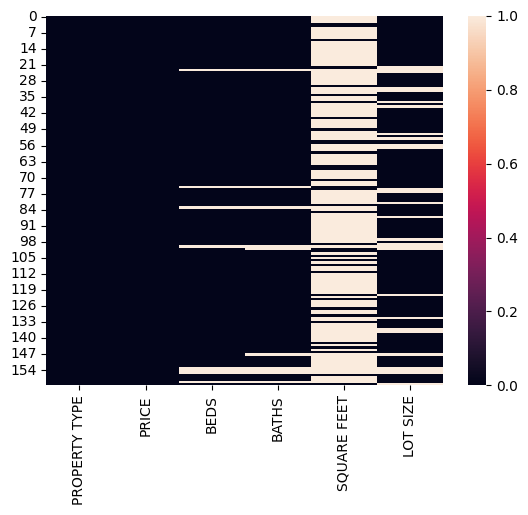

In [ ]:
sns.heatmap(r_data.isnull(), cbar=True)
r_data.info()

**Q5:** The histogram shows the frequency in how much data we have to each different sections of property type. It shows what data we have and how it effects the null data.

array(['Multi-Family (2-4 Unit)', 'Condo/Co-op',
       'Single Family Residential', 'Vacant Land', 'Townhouse',
       'Multi-Family (5+ Unit)'], dtype=object)

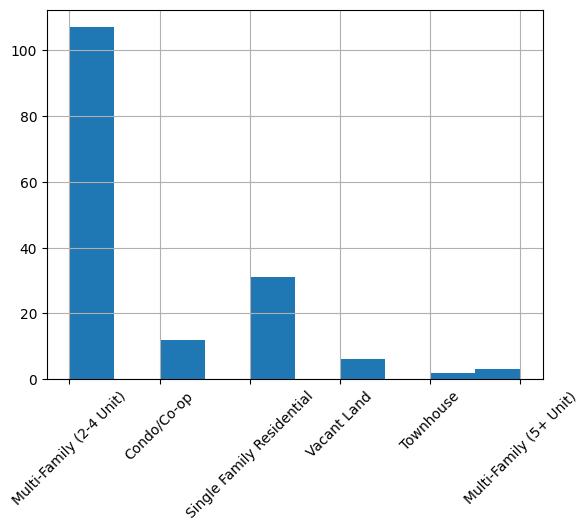

In [ ]:
r_data['PROPERTY TYPE'].hist(xrot=45.0)
r_data['PROPERTY TYPE'].unique()

**Q6:** After removing the Vacant Lands and 5+ Units we are left with the remaining data. The effect it had was it removed most of the missing percentage of data in beds and baths considering that it was vacant land (which makes sense) as well as multi-families. Those two removed had little effect on Sqr feet and Lot Size values missing which is shown in the heatmap below. Multi-family gets removed because it was cause problems since it is and will have different values due to these units being unique, The vacant land has no properties and as shown will mess up with our data with the beds and baths.

In [ ]:
property_remove = ['Vacant Land', 'Multi-Family (5+ Unit)']
r_data.drop(r_data[r_data['PROPERTY TYPE'].isin(property_remove)].index, inplace=True)

In [ ]:
r_data['PROPERTY TYPE'].unique()

array(['Multi-Family (2-4 Unit)', 'Condo/Co-op',
       'Single Family Residential', 'Townhouse'], dtype=object)

<Axes: >

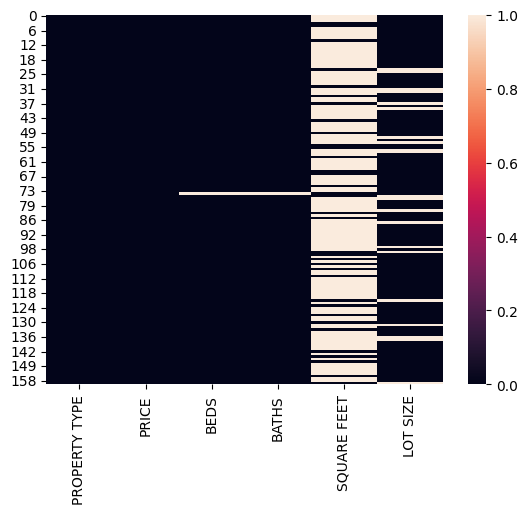

In [ ]:
sns.heatmap(r_data.isnull(), cbar=True)

7. Build a pairplot to evaluate data distributions and correlations.
8. Comment whether the predictors: 1) have a linear relationship with the target (Price), 2) display constant variance (homoscedasticity), 3) contain outliers that need to be excluded.

5 pts.

**Q7:** This scattter plot on price shows us there is multicollinearity within beds and bath and we can see that it is possible that it is true by looking and beds and baths scatter plot and see some kind of linear pattern. This might cause error with the data that'll make it less accurate and throw it off. When there is more beds and/or more baths the price goes up as well. we can not tell how much the frequency is with the data. A joinplot will help see futher into it.

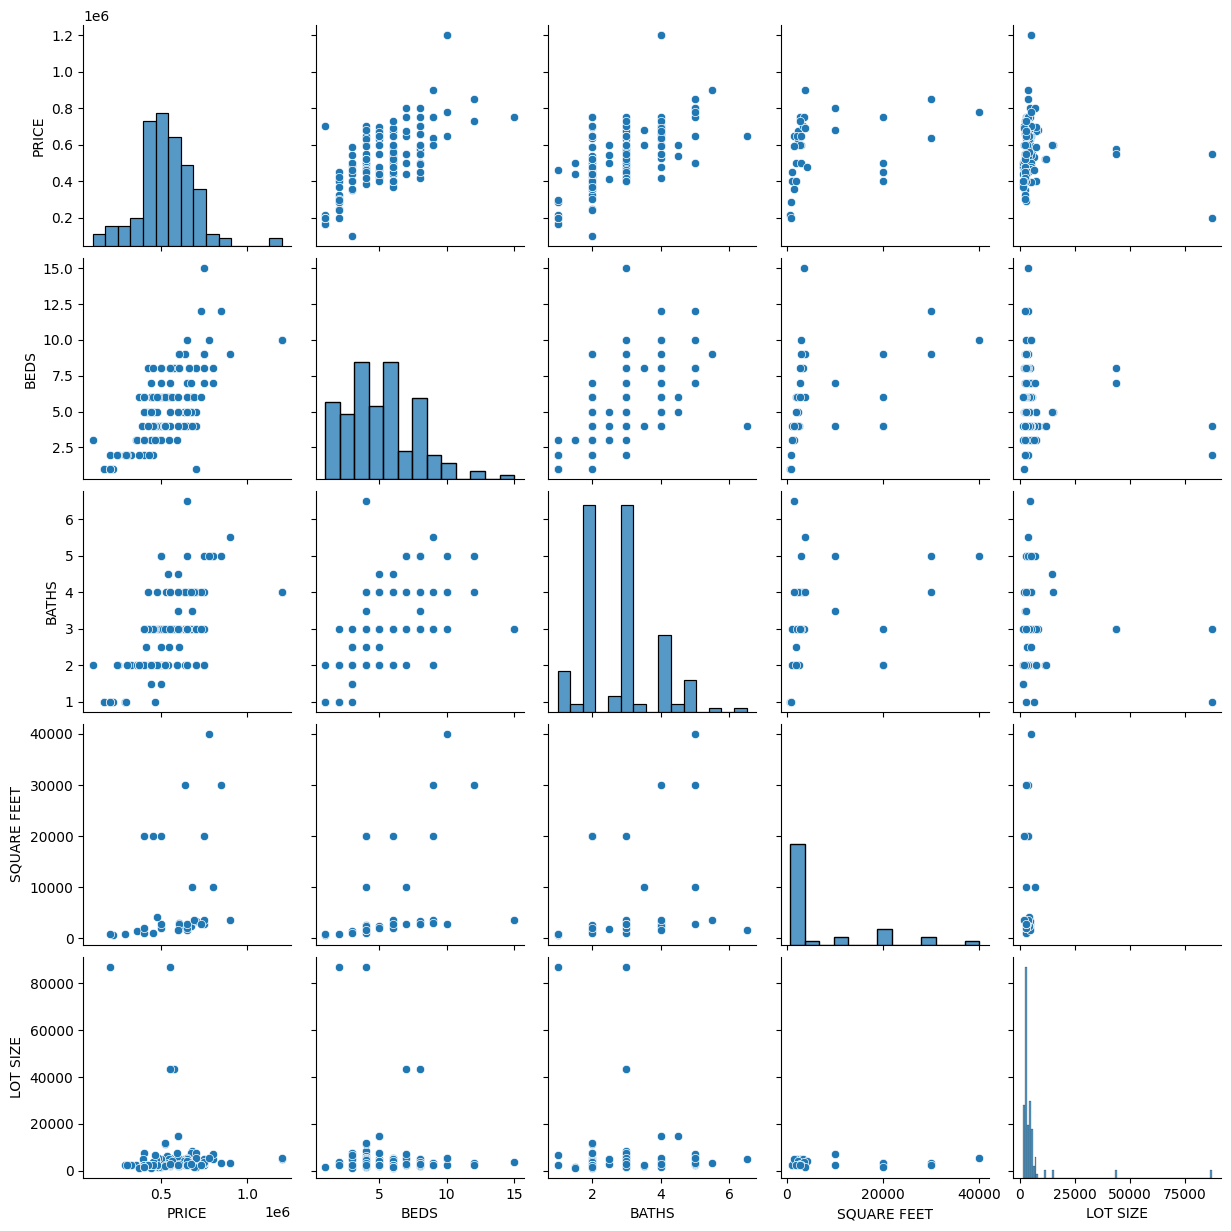

In [ ]:
sns.pairplot(r_data)

**Part of Q6:** The Joint Plot shows that the beds frequency does off after 8 and everything outside of it is a unique property (Outlier).

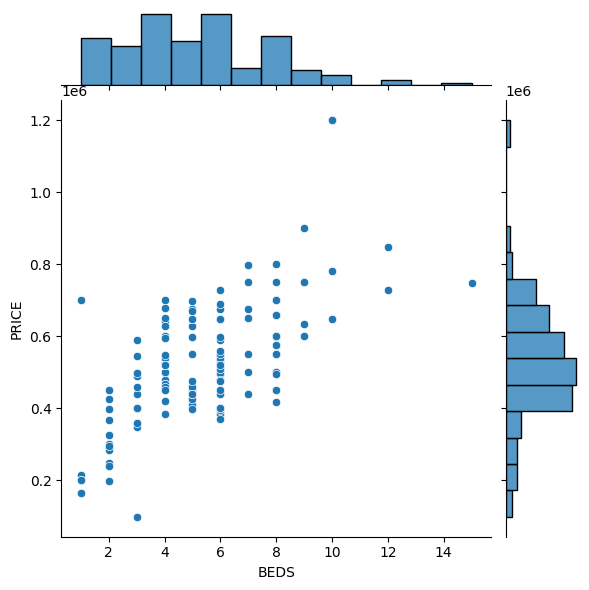

In [ ]:
sns.jointplot(x="BEDS", y="PRICE", data=r_data);

**Q8:** It seems that the beds and baths have a linear relation with the price as the square feet and lot size doesn't seem like it does but will be more clear with outliers removed. The pairplot shows that it could have constant variance with the beds and baths as well but for the square feet and lot size it has to be a no. All the variables connected to the target(price) has outliers shown above with data that seems to be far off. (ex. million dollar homes compared to avg.)

9. Remove outliers if necessary.
10. Impute missing values as appropriate.

2 pts.


The code below shoes that the min and max of all data as well as the count which is what I'm looking at. The Min of most of them are accurate and have at least 1 bed and bath, the max seems off. 15 beds and 6.5 baths seems like houses that are way off the mean of its data. Max of Sqr Feet and Lot Size also seem to be off and might also be outliers that need to be removed. The count is the most important since it shows what values are missing. Out of 151 data sqr feet is missing 116 (77%) of its data which even filling with mean will still cause issues since we don't have enough data to be accurate. Lot size is missing 20 data sets which should'nt be a problem.

In [ ]:
r_data.describe()

,PRICE,BEDS,BATHS,SQUARE FEET,LOT SIZE
count,1.520000e+02,151.000000,151.000000,35.000000,131.000000
mean,5.293807e+05,5.311258,2.794702,7438.228571,5645.679389
std,1.648515e+05,2.479746,1.047651,10039.082343,11521.981263
min,9.900000e+04,1.000000,1.000000,717.000000,1294.000000
25%,4.399000e+05,4.000000,2.000000,1965.000000,2500.000000
50%,5.199500e+05,5.000000,3.000000,2800.000000,2901.000000
75%,6.360000e+05,7.000000,3.000000,7099.000000,4791.000000
max,1.200000e+06,15.000000,6.500000,39996.000000,87120.000000


**Q9:** I dropped both the Sqr feet and Lot Size of anything more than 10k and 12k in size because it seems like it doesn't have anything related to rest of the data but it seems to have dropped another 13 data sets in sqr feet and 26 in Lot Size which might make the modeling worse but I needed to put it in place so their more accuracy in the data

In [ ]:
r_data.drop(r_data[r_data['SQUARE FEET'] > 10000 ].index, inplace=True)
r_data.drop(r_data[r_data['LOT SIZE'] > 12500 ].index, inplace=True)
r_data.drop(r_data[r_data['BEDS'] > 8 ].index, inplace=True)
r_data.describe()

,PRICE,BEDS,BATHS,SQUARE FEET,LOT SIZE
count,126.000000,125.000000,125.000000,22.000000,105.000000
mean,501076.023810,4.840000,2.692000,2143.727273,3447.961905
std,136788.609067,2.021657,0.997545,950.902888,1546.730845
min,99000.000000,1.000000,1.000000,717.000000,1294.000000
25%,424999.250000,3.000000,2.000000,1522.000000,2500.000000
50%,499000.000000,5.000000,3.000000,2049.000000,2613.000000
75%,599749.250000,6.000000,3.000000,2749.500000,4791.000000
max,799999.000000,8.000000,6.500000,4199.000000,8320.000000


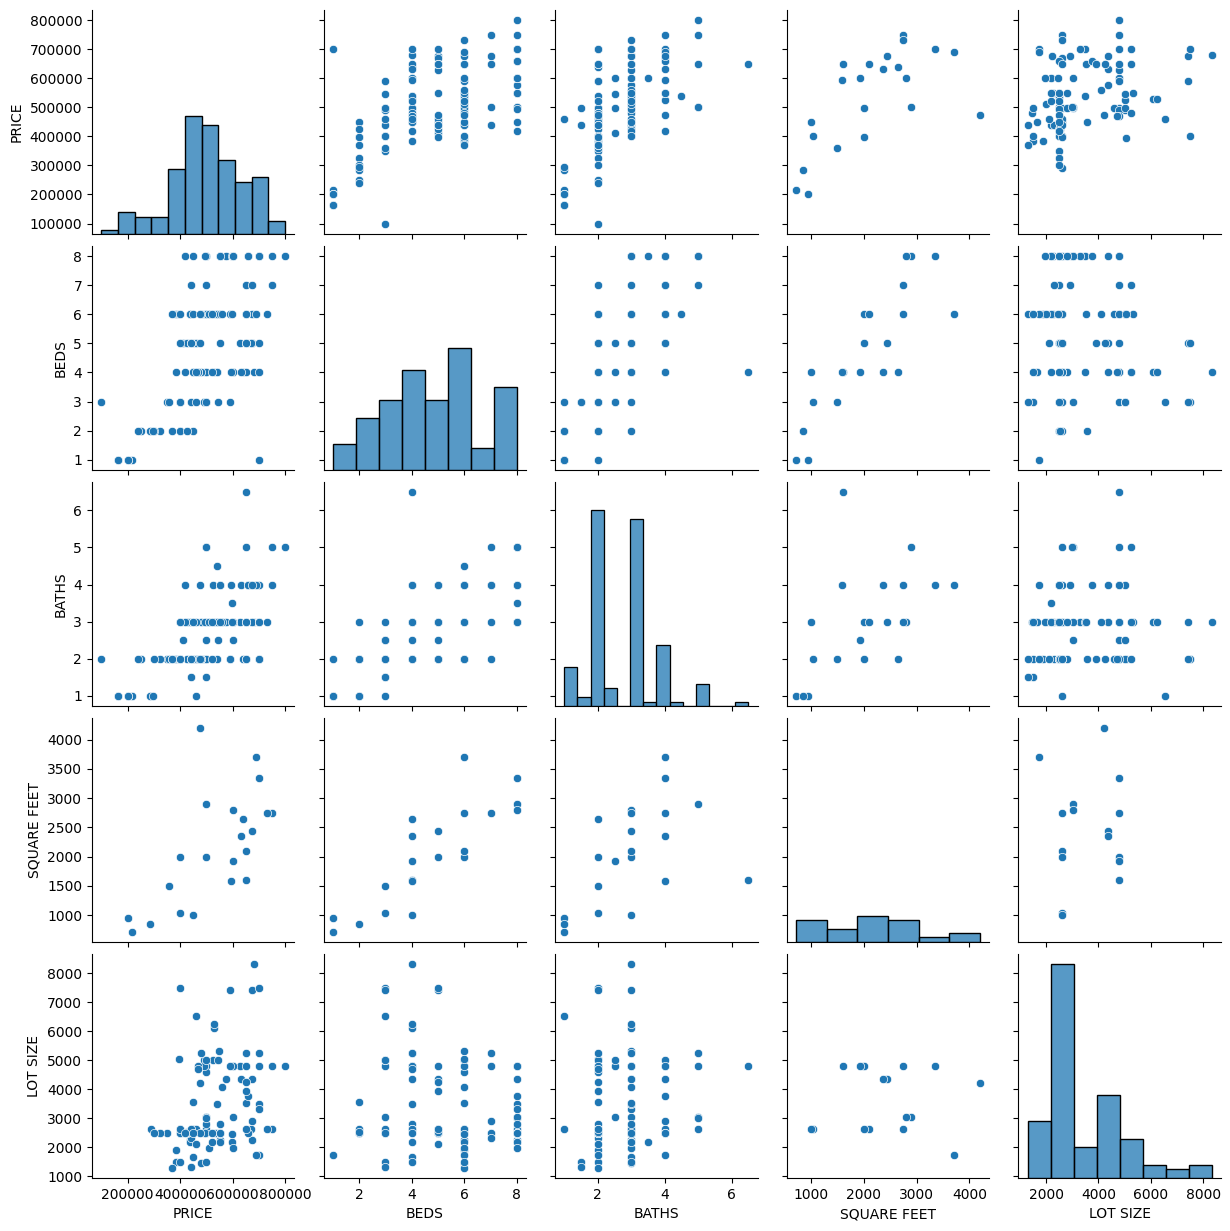

In [ ]:
sns.pairplot(r_data)

**Q10:** Here I added the imputed data of all the numericals where it takes the mean of PRICE, LOT SIZE, SQUARE FEET, BEDS and BATHS and fills all nulls with the mean. I then checked it and all the nulls were filled and I was left with 126 individual data entries.

In [ ]:
imputed = r_data[['PRICE', 'LOT SIZE', 'SQUARE FEET', 'BATHS', 'BEDS']].fillna(r_data[['PRICE', 'LOT SIZE', 'SQUARE FEET', 'BATHS', 'BEDS']].mean())
imputed.insert(1, 'PROPERTY TYPE', r_data['PROPERTY TYPE'])

In [ ]:
imputed.columns
predictors = imputed[['PROPERTY TYPE', 'BEDS', 'BATHS', 'SQUARE FEET', 'LOT SIZE']]

In [ ]:
imputed.columns
imputed.info()

<class 'pandas.core.frame.DataFrame'>
Index: 126 entries, 0 to 160
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   PRICE          126 non-null    int64  
 1   PROPERTY TYPE  126 non-null    object 
 2   LOT SIZE       126 non-null    float64
 3   SQUARE FEET    126 non-null    float64
 4   BATHS          126 non-null    float64
 5   BEDS           126 non-null    float64
dtypes: float64(4), int64(1), object(1)
memory usage: 6.9+ KB


11. Split data 70/30 into training and test datasets.
12. Build a multiple linear regression model to predict Price.
13. Report R2, MAE, Max error, RMSE.
14. Comment on whether the model performance would be acceptable for practitioners.

7 pts.

**Q11:** Here I made a test model where it tests 70 percent of the data and uses 30 percent to use the data for our model. This model is made to compare the target variable (Price) to the actual Price we have which would be our 126 entries. The dummy code takes the multinomial data and converts them into numerical numbers so it can be used in the model.

In [ ]:
X = pd.get_dummies(imputed[predictors.columns], drop_first=True)
y = imputed['PRICE']

train_X, valid_X, train_y, valid_y = train_test_split(X, y, test_size=0.3, random_state=1)

**Q12:** Here we use the Linear Regression to see
that the intercept of our starting point is 90k which shows where we start, our coefficent has no negitives which means every point (ex. beds, baths, etc.) are adding to the value of each property.

In [ ]:
re_prices = LinearRegression()

re_prices.fit(train_X, train_y)

LinearRegression()

In [ ]:
re_prices.intercept_

90508.12382262934

In [ ]:
re_prices.coef_

array([1.81165429e+04, 3.89351023e+04, 2.98587185e+00, 2.49073573e+01,
       1.51233237e+05, 7.50936753e+04, 8.71080717e+04])

In [ ]:
train_X.head()

,BEDS,BATHS,SQUARE FEET,LOT SIZE,PROPERTY TYPE_Multi-Family (2-4 Unit),PROPERTY TYPE_Single Family Residential,PROPERTY TYPE_Townhouse
58,8.0,3.0,2143.727273,2500.0,True,False,False
70,8.0,3.5,2143.727273,2178.0,True,False,False
124,2.0,2.0,2143.727273,3550.0,True,False,False
11,6.0,4.0,2143.727273,5001.0,True,False,False
98,8.0,4.0,2143.727273,3751.0,True,False,False


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, max_error, r2_score, explained_variance_score

In [ ]:
pred_y = re_prices.predict(valid_X)

**Q13:**

In [ ]:
print('Regression model performance evaluation')
print('R2: ', r2_score(valid_y, pred_y))
print('MAE: ', mean_absolute_error(valid_y, pred_y))
print('RMSE: ', math.sqrt(mean_squared_error(valid_y, pred_y)))
print('Max error: ', max_error(valid_y, pred_y))

Regression model performance evaluation
R2:  0.5238390676817212
MAE:  77545.62995820488
RMSE:  99836.73461290973
Max error:  312481.3800097767


**Question 14:** The model would not be excellent for practitioners because our R2 shows us that it is not completely accurate with the test and we are missing alot of data. We can check that by seeing the MAE 77.5k for the properties and the average it is off by. The RMSE and Max Error adds to it by showing that almost 100k as the difference from the actual data and Max error is showing that the max difference is 312k. Usually as discussed in class, the max error should be around 5-7% but this is way beyond that. This model is a very early one that can not be used.

